In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

quarterly = pd.read_csv('../data/processed/quarterly_level_clean.csv')
quarterly = quarterly.sort_values(['year', 'quarter']).reset_index(drop=True)
quarterly.shape

(199, 31)

In [2]:
modelo_df = quarterly.dropna(subset=['target_patent_count_next_quarter']).copy()
print(modelo_df.shape)  # debería ser (198, 31) — perdimos solo 1 fila

(198, 31)


In [3]:
features = [
    'patent_count', 'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy',
    'kw_5g_count', 'kw_ai_ml_count', 'kw_cloud_edge_count', 'kw_security_count',
    'kw_iot_count', 'kw_network_count', 'kw_energy_count', 'kw_antenna_count', 'kw_data_count',
    'avg_title_words', 'avg_keyword_score',
    'quarter'  # para capturar cualquier resto de estacionalidad
]

X = modelo_df[features]
y = modelo_df['target_patent_count_next_quarter']

print(X.shape, y.shape)
X.isna().sum().sum()  # debería dar 0

(198, 20) (198,)


np.int64(0)

In [4]:
split_point = int(len(modelo_df) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train años:", modelo_df.iloc[:split_point][['year','quarter']].iloc[[0,-1]])
print("Test años:", modelo_df.iloc[split_point:][['year','quarter']].iloc[[0,-1]])

Train: (158, 20) | Test: (40, 20)
Train años:      year  quarter
0    1976        1
157  2015        2
Test años:      year  quarter
158  2015        3
197  2025        2


In [5]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)

pred_ridge = modelo_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print(f"Ridge -> MAE: {mae_ridge:.2f} | RMSE: {rmse_ridge:.2f} | R²: {r2_ridge:.3f}")

Ridge -> MAE: 53.91 | RMSE: 62.81 | R²: -0.961


In [6]:
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f"Random Forest -> MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.3f}")

Random Forest -> MAE: 41.30 | RMSE: 51.26 | R²: -0.307


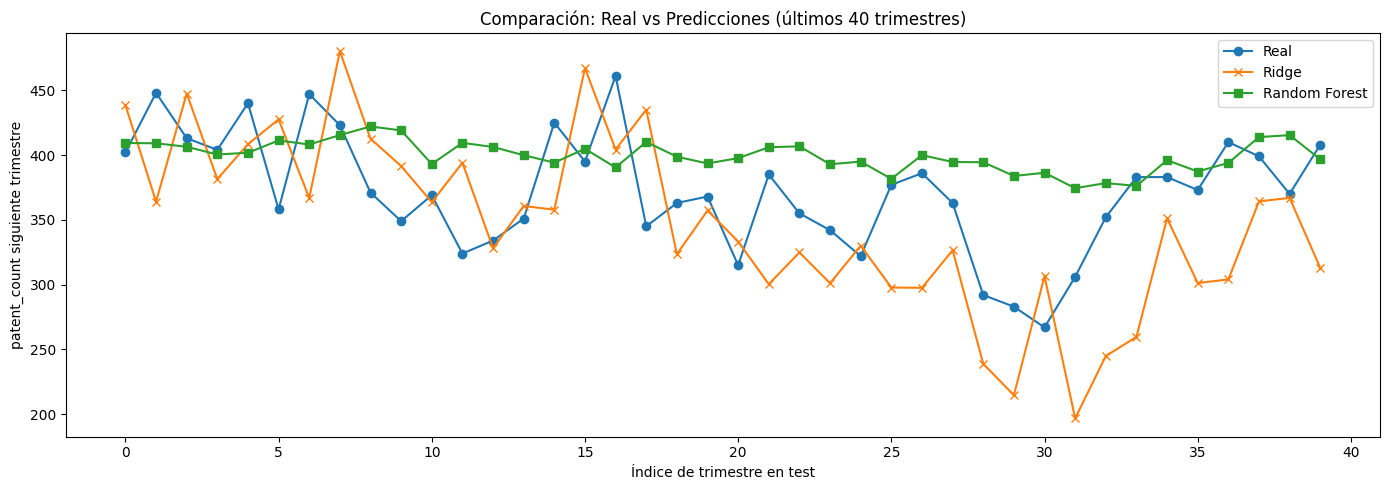

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Real', marker='o')
plt.plot(pred_ridge, label='Ridge', marker='x')
plt.plot(pred_rf, label='Random Forest', marker='s')
plt.title('Comparación: Real vs Predicciones (últimos 40 trimestres)')
plt.xlabel('Índice de trimestre en test')
plt.ylabel('patent_count siguiente trimestre')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Baseline: predecir que el próximo trimestre será igual al actual
pred_naive = X_test['patent_count'].values

mae_naive = mean_absolute_error(y_test, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))
r2_naive = r2_score(y_test, pred_naive)

print(f"Naive -> MAE: {mae_naive:.2f} | RMSE: {rmse_naive:.2f} | R²: {r2_naive:.3f}")

Naive -> MAE: 35.35 | RMSE: 43.93 | R²: 0.040


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_ridge2 = Ridge(alpha=1.0)
modelo_ridge2.fit(X_train_scaled, y_train)
pred_ridge2 = modelo_ridge2.predict(X_test_scaled)

mae_r2 = mean_absolute_error(y_test, pred_ridge2)
rmse_r2 = np.sqrt(mean_squared_error(y_test, pred_ridge2))
r2_r2 = r2_score(y_test, pred_ridge2)

print(f"Ridge (escalado) -> MAE: {mae_r2:.2f} | RMSE: {rmse_r2:.2f} | R²: {r2_r2:.3f}")

Ridge (escalado) -> MAE: 203.78 | RMSE: 268.15 | R²: -34.746


In [10]:
modelo_rf2 = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=42)
modelo_rf2.fit(X_train, y_train)
pred_rf2 = modelo_rf2.predict(X_test)

mae_rf2 = mean_absolute_error(y_test, pred_rf2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test, pred_rf2))
r2_rf2 = r2_score(y_test, pred_rf2)

print(f"Random Forest v2 -> MAE: {mae_rf2:.2f} | RMSE: {rmse_rf2:.2f} | R²: {r2_rf2:.3f}")

Random Forest v2 -> MAE: 38.56 | RMSE: 48.83 | R²: -0.185


In [11]:
for alpha_val in [1, 10, 50, 100, 300, 1000]:
    modelo_temp = Ridge(alpha=alpha_val)
    modelo_temp.fit(X_train_scaled, y_train)
    pred_temp = modelo_temp.predict(X_test_scaled)
    r2_temp = r2_score(y_test, pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, pred_temp))
    print(f"alpha={alpha_val:5d} -> RMSE: {rmse_temp:.2f} | R²: {r2_temp:.3f}")

alpha=    1 -> RMSE: 268.15 | R²: -34.746
alpha=   10 -> RMSE: 333.37 | R²: -54.251
alpha=   50 -> RMSE: 203.18 | R²: -19.523
alpha=  100 -> RMSE: 112.12 | R²: -5.249
alpha=  300 -> RMSE: 62.37 | R²: -0.934
alpha= 1000 -> RMSE: 100.70 | R²: -4.041


In [12]:
features_reducido = [
    'patent_count_lag1',        # solo el trimestre inmediato anterior
    'patent_count_roll4_mean',  # tendencia de 1 año
    'patent_count_yoy',         # crecimiento interanual
    'kw_5g_count', 'kw_ai_ml_count', 'kw_iot_count', 'kw_cloud_edge_count',
    'avg_keyword_score',
    'quarter'
]

X2 = modelo_df[features_reducido]
X2_train, X2_test = X2.iloc[:split_point], X2.iloc[split_point:]

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

modelo_ridge3 = Ridge(alpha=10.0)
modelo_ridge3.fit(X2_train_scaled, y_train)
pred_ridge3 = modelo_ridge3.predict(X2_test_scaled)

print(f"Ridge (features reducidas) -> RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridge3)):.2f} | R²: {r2_score(y_test, pred_ridge3):.3f}")

Ridge (features reducidas) -> RMSE: 191.70 | R²: -17.271


In [13]:
print("=== Target (patent_count_next_quarter) ===")
print("Train -> min:", y_train.min(), "max:", y_train.max(), "media:", y_train.mean().round(1))
print("Test  -> min:", y_test.min(), "max:", y_test.max(), "media:", y_test.mean().round(1))

=== Target (patent_count_next_quarter) ===
Train -> min: 1.0 max: 525.0 media: 96.5
Test  -> min: 267.0 max: 461.0 media: 371.5


In [14]:
modelo_df['target_delta'] = modelo_df['target_patent_count_next_quarter'] - modelo_df['patent_count']

print("=== target_delta ===")
print("Train sería -> min:", modelo_df['target_delta'].iloc[:split_point].min(),
      "max:", modelo_df['target_delta'].iloc[:split_point].max(),
      "media:", modelo_df['target_delta'].iloc[:split_point].mean().round(1))
print("Test sería  -> min:", modelo_df['target_delta'].iloc[split_point:].min(),
      "max:", modelo_df['target_delta'].iloc[split_point:].max(),
      "media:", modelo_df['target_delta'].iloc[split_point:].mean().round(1))

=== target_delta ===
Train sería -> min: -107.0 max: 100.0 media: 2.5
Test sería  -> min: -116.0 max: 89.0 media: -0.0


In [16]:
y_delta = modelo_df['target_delta']
y_delta_train, y_delta_test = y_delta.iloc[:split_point], y_delta.iloc[split_point:]

# --- Ridge con features reducidas (ya escaladas: X2_train_scaled, X2_test_scaled) ---
modelo_ridge_delta = Ridge(alpha=10.0)
modelo_ridge_delta.fit(X2_train_scaled, y_delta_train)
pred_delta_ridge = modelo_ridge_delta.predict(X2_test_scaled)

# --- Random Forest con features originales (X_train, X_test) ---
modelo_rf_delta = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=42)
modelo_rf_delta.fit(X_train, y_delta_train)
pred_delta_rf = modelo_rf_delta.predict(X_test)

# --- Reconstruir la predicción del NIVEL sumando el delta al valor actual ---
pred_nivel_ridge = modelo_df['patent_count'].iloc[split_point:].values + pred_delta_ridge
pred_nivel_rf = modelo_df['patent_count'].iloc[split_point:].values + pred_delta_rf

# --- Evaluar en la escala del NIVEL (para comparar contra ARIMA y naive) ---
print("Ridge (vía delta) -> RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_nivel_ridge)), 2),
      "| R²:", round(r2_score(y_test, pred_nivel_ridge), 3))
print("RF (vía delta)    -> RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_nivel_rf)), 2),
      "| R²:", round(r2_score(y_test, pred_nivel_rf), 3))

Ridge (vía delta) -> RMSE: 108.92 | R²: -4.898
RF (vía delta)    -> RMSE: 45.13 | R²: -0.013


In [17]:
print("Delta real (test)      -> min:", y_delta_test.min(), "max:", y_delta_test.max())
print("Delta predicho (Ridge) -> min:", pred_delta_ridge.min().round(1), "max:", pred_delta_ridge.max().round(1))
print()
print("Primeros 10 valores predichos por Ridge:", pred_delta_ridge[:10].round(1))

Delta real (test)      -> min: -116.0 max: 89.0
Delta predicho (Ridge) -> min: -239.0 max: 18.1

Primeros 10 valores predichos por Ridge: [  9.3 -21.  -10.9 -15.1   4.8 -16.9  14.7  10.9  11.   -2.7]


In [18]:
for alpha_val in [10, 50, 100, 200, 500]:
    modelo_temp = Ridge(alpha=alpha_val)
    modelo_temp.fit(X2_train_scaled, y_delta_train)
    pred_temp_delta = modelo_temp.predict(X2_test_scaled)
    pred_temp_nivel = modelo_df['patent_count'].iloc[split_point:].values + pred_temp_delta
    rmse_temp = round(np.sqrt(mean_squared_error(y_test, pred_temp_nivel)), 2)
    r2_temp = round(r2_score(y_test, pred_temp_nivel), 3)
    print(f"alpha={alpha_val:4d} -> RMSE: {rmse_temp} | R²: {r2_temp} | delta pred range: [{pred_temp_delta.min():.1f}, {pred_temp_delta.max():.1f}]")

alpha=  10 -> RMSE: 108.92 | R²: -4.898 | delta pred range: [-239.0, 18.1]
alpha=  50 -> RMSE: 85.39 | R²: -2.625 | delta pred range: [-177.0, 12.5]
alpha= 100 -> RMSE: 73.34 | R²: -1.674 | delta pred range: [-142.7, 9.9]
alpha= 200 -> RMSE: 61.56 | R²: -0.884 | delta pred range: [-106.0, 7.8]
alpha= 500 -> RMSE: 49.73 | R²: -0.229 | delta pred range: [-60.2, 5.5]


In [19]:
for alpha_val in [500, 800, 1200, 2000, 3000, 5000]:
    modelo_temp = Ridge(alpha=alpha_val)
    modelo_temp.fit(X2_train_scaled, y_delta_train)
    pred_temp_delta = modelo_temp.predict(X2_test_scaled)
    pred_temp_nivel = modelo_df['patent_count'].iloc[split_point:].values + pred_temp_delta
    rmse_temp = round(np.sqrt(mean_squared_error(y_test, pred_temp_nivel)), 2)
    r2_temp = round(r2_score(y_test, pred_temp_nivel), 3)
    print(f"alpha={alpha_val:5d} -> RMSE: {rmse_temp} | R²: {r2_temp} | delta pred range: [{pred_temp_delta.min():.1f}, {pred_temp_delta.max():.1f}]")

alpha=  500 -> RMSE: 49.73 | R²: -0.229 | delta pred range: [-60.2, 5.5]
alpha=  800 -> RMSE: 46.46 | R²: -0.073 | delta pred range: [-41.5, 4.6]
alpha= 1200 -> RMSE: 44.95 | R²: -0.005 | delta pred range: [-29.0, 4.0]
alpha= 2000 -> RMSE: 44.12 | R²: 0.032 | delta pred range: [-17.6, 3.5]
alpha= 3000 -> RMSE: 43.9 | R²: 0.042 | delta pred range: [-11.3, 3.2]
alpha= 5000 -> RMSE: 43.84 | R²: 0.044 | delta pred range: [-6.0, 2.9]


## Conclusiones del modelado predictivo

1. El ARIMA(0,1,1) con drift ajustado en R fue el modelo con mejor desempeño**
   (RMSE=29.05), superando tanto al baseline naive como a los modelos de ML.

2. Predecir el nivel absoluto (`patent_count_next_quarter`) directamente 
   con Ridge/Random Forest fracasó** debido a un cambio de régimen entre 
   train y test: el split 80/20 dejó valores de train mayormente bajos 
   (media 96.5) y de test mayormente altos (media 371.5), forzando a los 
   modelos a extrapolar fuera del rango visto en entrenamiento.

3. Al reformular el problema como predicción del cambio (`delta`) en vez 
   del nivel** —la misma lógica de diferenciación que usa ARIMA con d=1—, 
   Random Forest mejoró sustancialmente (de R²=-0.307 a R²=-0.013), 
   acercándose al desempeño del naive.

4. Ridge, incluso reformulado con delta, no logró superar al baseline 
   naive**: con regularización baja sufría inestabilidad numérica 
   (multicolinealidad entre features de historia reciente), y con 
   regularización alta convergía exactamente al comportamiento del naive 
   (predecir "sin cambio").

5. Conclusión general**: para esta serie de tiempo específica, un modelo 
   estadístico especializado (ARIMA) superó a los enfoques de ML genéricos. 
   Esto es consistente con la literatura: series con tendencia fuerte y 
   pocas observaciones (199 trimestres) favorecen modelos que incorporan 
   explícitamente la estructura temporal, mientras que Ridge y Random 
   Forest —diseñados para datos tabulares "planos"— necesitan mucha 
   ingeniería de features adicional para igualar ese desempeño.